### Necessary Imports

In [ ]:
from astropy.table import Table
from astropy.io.votable import parse
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib
import requests

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### Now let's read in all our good CNN predicted periods

In [3]:
reportable = pd.read_csv('reportable.csv', index_col='Unnamed: 0').rename(columns={'edr3_source_id':'EDR3'})
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### And divide them into their subpopulations

In [4]:
cold = reportable[reportable['bp-rp'] >= 0.6]
hot = reportable[reportable['bp-rp'] < 0.6]

oscillators = cold[cold['abs_g_mag'] <= ((2*cold['bp-rp']) - 4)]
nonoscillators = cold[cold['abs_g_mag'] > ((2*cold['bp-rp']) - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < ((1.4*nonoscillators['bp-rp'])+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= ((1.4*nonoscillators['bp-rp'])+2.8)]

## We want to plot our cool star predictions in Period-Color space to see if we can reproduce the intermediate period gap. To do this, we have to do a few things
#### 1. Import the Santos files so that we have a comparison sample that does possess the intermediate period gap
#### 2. Take the 'Kepler meets Gaia DR3" A1 table from Godoy-Rivera et al. (2025, https://ui.adsabs.harvard.edu/abs/2025A%26A...696A.243G/abstract) to get DR3 IDs so that we can get Gaia G and Rp colors for the Santos stars (need to drop the 2MASS column for import onto ESA Cosmos)
#### 3. Import the combined Gaia/Godoy-Rivera table and cross-match that to the Santos catalog to make a list of Santos stars with gaia G and Rp magnitudes
#### 4. Plot both populations as well as the period gap as defined in Gordon et al. (2021, https://ui.adsabs.harvard.edu/abs/2021ApJ...913...70G/abstract)

In [11]:
santos1 = Table.read('files/crossmatch/santos1.txt', format="ascii.cds").to_pandas()
santos2 = Table.read('files/crossmatch/santos2.txt', format="ascii.cds").to_pandas()

santostot = pd.concat([santos1, santos2])

del santos1, santos2

In [12]:
url_godoy_rivera = "https://zenodo.org/records/14774100/files/GodoyRivera25_TableA1.csv?download=1"
query_parameters = {"downloadformat": "csv"}
response = requests.get(url_godoy_rivera, params=query_parameters)
with open("godoyrivera.csv", mode="wb") as file:
    file.write(response.content)

In [13]:
keplergaiamatch_before = pd.read_csv('godoyrivera.csv').drop(columns=['2MASS'])
keplergaiamatch_before.to_csv('pregaia_godoyrivera.csv')

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_42138/367891243.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  keplergaiamatch_before = pd.read_csv('godoyrivera.csv').drop(columns=['2MASS'])


## now is when you would take the saved 'pregaia_godoyrivera.csv' file and import it to the ESA Gaia archive (https://gea.esac.esa.int/archive/) to get color information.

### The ADQL query we used to get necessary information (after importing the table as 'godoyrivera') was:

```
SELECT cross3.dr3_source_id,  gsource.phot_g_mean_mag, gsource.phot_bp_mean_mag, gsource.phot_rp_mean_mag, mine.*, gsource.source_id AS dr2_id1, cross3.dr2_source_id AS dr2_id2
FROM gaiadr3.dr2_neighbourhood AS cross3 
INNER JOIN user_mschoche.godoyrivera AS mine ON mine.dr3_source_id=cross3.dr3_source_id
INNER JOIN gaiadr2.gaia_source AS gsource ON cross3.dr2_source_id=gsource.source_id

```

In [14]:
keplergaiamatch_final = parse('1753968185448O-result.vot').get_first_table().to_table().to_pandas().drop_duplicates(subset=['dr3_source_id'])
keplergaiamatch_final.drop(columns=['godoyrivera_oid', 'col1', 'dr3_source_id_2'], inplace=True)

In [15]:
idmatch = Table.read('files/kepler_dr2_1arcsec.fits', format='fits').to_pandas()
idmatch = idmatch.drop_duplicates(subset=['kepid'])
idmatcher = idmatch[['kepid', 'source_id']]
idmatcher = idmatcher.rename(columns={'kepid':'KIC', 'source_id':'dr2_source_id'})
dr2matched = pd.merge(keplergaiamatch_final, idmatcher, on='KIC', how='inner')
del keplergaiamatch_final, idmatcher, keplergaiamatch_before

In [ ]:
combined = pd.merge(santostot, dr2matched, on='KIC', how='inner', suffixes=(None, '_y'))
del santostot

In [21]:
ms = ms[ms['phot_g_mean_mag']<15]
ms['g_rp'] = ms['phot_g_mean_mag'] - ms['phot_rp_mean_mag']
combined['g_rp'] = combined['phot_g_mean_mag'] - combined['phot_rp_mean_mag']

# Now let's make our period gap boundaries

validrange = combined[(combined['g_rp']>0.8) & (combined['g_rp']<1.05)]
edgetop = (68.2277*(validrange['g_rp']+0.0653))-(43.7301*((validrange['g_rp']+0.0653)**0.5))
edgebot = (34.0405*(validrange['g_rp']-0.3150))-(2.6183*((validrange['g_rp']-0.3150)**0.5))

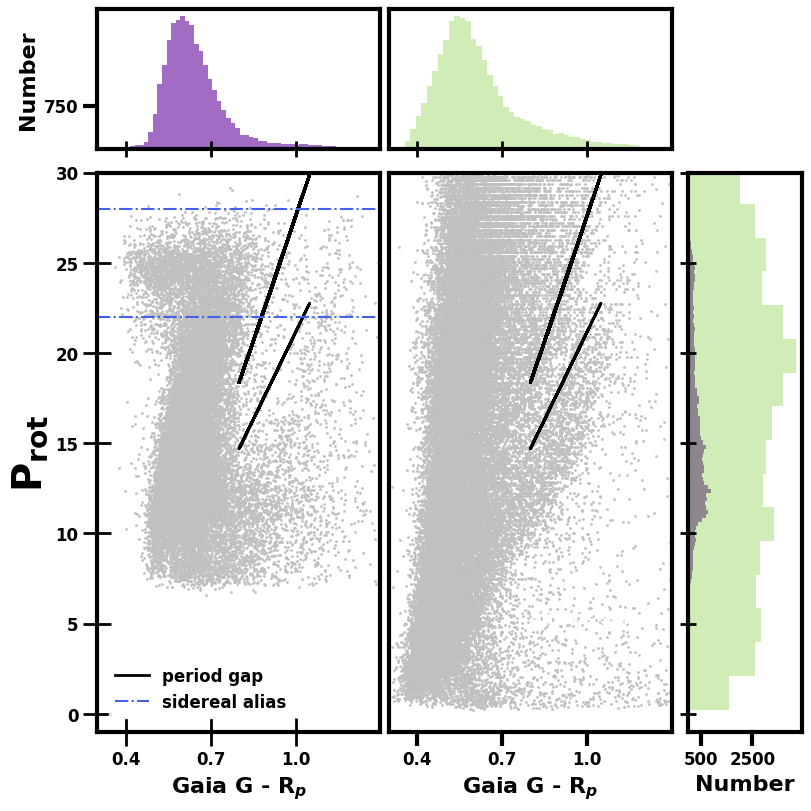

In [ ]:
fig = plt.figure(figsize=(8, 8), layout='constrained')
prote = r'P$_{\rm{rot}}$'
gs = fig.add_gridspec(2, 3,  width_ratios=(5, 5, 2), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0, hspace=0)
axs = fig.add_subplot(gs[1, 0]) #main our periods plpt
axs2 = fig.add_subplot(gs[1, 1]) #santos periods plot

ax_histx = fig.add_subplot(gs[0, 0], sharex=axs) #us color histogram
ax_histx2 = fig.add_subplot(gs[0, 1], sharex=axs2) #santos color histogram
ax_histy = fig.add_subplot(gs[1, 2], sharey=axs) #combined period histogram

axs.set(xlim = (0.3, 1.3), ylim = (-1, 30), ylabel=prote)
axs2.set(xlim = (0.3, 1.3), ylim = (-1, 30))
[ax.set_xlabel(f'Gaia G - R$_p$', fontsize=16) for ax in [axs, axs2]]
[ax.set_xticks(labels=[0.4, 0.7, 1.0], ticks=[0.4, 0.7, 1.0], fontsize=12) for ax in [axs, axs2]]
[ax.set_yticks([]) for ax in [axs2, ax_histx2]]
axs.set_yticks(labels = [0, 5, 10, 15, 20, 25, 30], ticks = [0, 5, 10, 15, 20, 25, 30], fontsize=12)
ax_histx.set_yticks(labels = [750, 2500], ticks = [750, 2500], fontsize=12)
ax_histy.set_xticks(labels = [500, 2500], ticks = [500, 2500] , fontsize=12)

[ax.tick_params(axis="x", labelbottom=False, top = False, right = False, length = 12, width = 2, direction = 'inout') for ax in [ax_histx, ax_histx2]]
ax_histx.set_ylabel('Number', fontsize=16)
ax_histy.set_xlabel('Number', fontsize=16)

axs.tick_params(which = 'both', direction = 'inout',  top=False, right=False, length=20, width=2)
axs.tick_params(which = 'minor', length = 12, width = 1)

ax_histy.tick_params(axis="y", labelleft=False, top = False, right = False, length = 12, width = 2, direction = 'inout')

mingrp = np.nanmin(combined['g_rp'].values)
maxgrp = np.nanmax(combined['g_rp'].values)
minp= np.nanmin(combined['Prot'].values)
maxp = np.nanmax(combined['Prot'].values)

im0 = axs2.scatter(combined['g_rp'],combined['Prot'],s=1,c='silver', rasterized=True)
im = axs.scatter(ms['g_rp'], ms['period'], s=1,c='silver', rasterized=True)

ax_histx.hist(ms['g_rp'], bins=100, color='#A36CC4', rasterized=True)
ax_histx2.hist(combined['g_rp'], bins=100, color='#64C615', alpha=0.3, rasterized=True)

ax_histy.hist(ms['period'], bins=100, color = '#A36CC4', orientation='horizontal', rasterized=True)
ax_histy.hist(combined['Prot'], bins=100, color = "#64C615", orientation='horizontal', alpha=0.3, rasterized=True)

axs.plot(validrange['g_rp'], edgetop, c="#000000", linewidth=2, label='period gap')
axs.plot(validrange['g_rp'], edgebot, c="#000000", linewidth=2)
axs.plot([0.3, 1.3], [22, 22], c="#4361EE", linestyle='-.', linewidth=1.5, label='sidereal alias')
axs.plot([0.3, 1.3], [28, 28], c="#4361EE", linestyle='-.', linewidth=1.5)

axs2.plot(validrange['g_rp'], edgetop, c="#000000", linewidth=2)
axs2.plot(validrange['g_rp'], edgebot, c="#000000", linewidth=2)

legend = axs.legend(loc='lower left', bbox_to_anchor=(0.01, 0.01), markerscale=3, fontsize=12)
frame = legend.get_frame()
frame.set_color('white')
axs2.text(0.8, 5, "Santos stars", c='white', fontsize=12)
fig.set_facecolor('w')
plt.show()